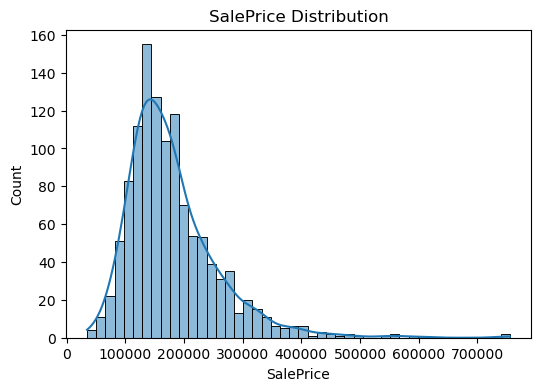

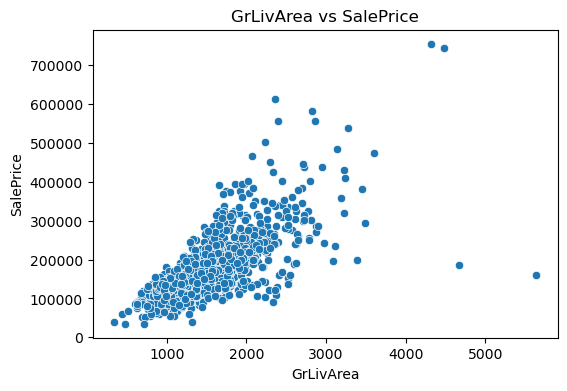

🎉 submission_final.csv 저장 완료


In [1]:
# =========================================================
# 0. 라이브러리
# =========================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.base import clone

# =========================================================
# 1. 데이터 불러오기
# =========================================================
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

# =========================================================
# 2. 데이터 이해 및 탐색 (평가 기준 충족)
# =========================================================
plt.figure(figsize=(6,4))
sns.histplot(train["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()

# =========================================================
# 3. 이상치 제거
# =========================================================
outlier_idx = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 500000)].index
train = train.drop(outlier_idx).reset_index(drop=True)

# =========================================================
# 4. 수제 전처리
# =========================================================
full_data = pd.concat([train, test]).reset_index(drop=True)

none_cols = ["PoolQC","MiscFeature","Alley","Fence","FireplaceQu",
             "GarageType","GarageFinish","GarageQual","GarageCond",
             "BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","MasVnrType"]
for col in none_cols:
    full_data[col] = full_data[col].fillna("None")

zero_cols = ["GarageYrBlt","GarageArea","GarageCars","BsmtFinSF1","BsmtFinSF2",
             "BsmtUnfSF","TotalBsmtSF","MasVnrArea","BsmtFullBath","BsmtHalfBath"]
for col in zero_cols:
    full_data[col] = full_data[col].fillna(0)

mode_cols = ["MSZoning","Electrical","KitchenQual","Exterior1st","Exterior2nd",
             "SaleType","Functional","Utilities"]
for col in mode_cols:
    full_data[col] = full_data[col].fillna(full_data[col].mode()[0])

full_data["LotFrontage"] = full_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

for c in ["MSSubClass","OverallCond","YrSold","MoSold"]:
    full_data[c] = full_data[c].astype(str)

full_data["TotalSF"] = full_data["TotalBsmtSF"] + full_data["1stFlrSF"] + full_data["2ndFlrSF"]

full_data = pd.get_dummies(full_data)

# =========================================================
# 5. 데이터 분리
# =========================================================
X = full_data.iloc[:len(train)].copy()
X_test = full_data.iloc[len(train):].copy()
y = np.log1p(train["SalePrice"])

X = X.drop(columns=["SalePrice"], errors="ignore")
X_test = X_test.drop(columns=["SalePrice"], errors="ignore")

# =========================================================
# 6. 모델 정의
# =========================================================
robust = RobustScaler()

lasso = make_pipeline(robust, LassoCV(max_iter=100000, random_state=42))
ela   = make_pipeline(robust, ElasticNetCV(max_iter=100000, random_state=42))
ridge = make_pipeline(robust, RidgeCV(alphas=[1,5,10,15,20]))

gbr = GradientBoostingRegressor(
    n_estimators=3000, learning_rate=0.01,
    max_depth=3, max_features='sqrt',
    loss='huber', random_state=42
)

base_models = [
    ("lasso", lasso),
    ("elastic", ela),
    ("ridge", ridge),
    ("gbr", gbr)
]

# =========================================================
# 7. 스태킹 앙상블
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros((X.shape[0], len(base_models)))
test_meta = np.zeros((X_test.shape[0], len(base_models)))

for m, (name, model) in enumerate(base_models):
    test_fold_preds = []

    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        instance = clone(model)
        instance.fit(X_tr, y_tr)

        oof[val_idx, m] = instance.predict(X_val)
        test_fold_preds.append(instance.predict(X_test))

    test_meta[:, m] = np.mean(test_fold_preds, axis=0)

meta = LassoCV(max_iter=10000, random_state=42)
meta.fit(oof, y)

final_pred = np.expm1(meta.predict(test_meta))

submission = pd.DataFrame({"Id": test["Id"], "SalePrice": final_pred})
submission.to_csv("submission_final.csv", index=False)

print("🎉 submission_final.csv 저장 완료")
